In [1]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from IPython.display import display
from scipy.special import chndtrinc, ncfdtrinc, ncfdtr
from scipy.stats import f, geom, ncf

[As discussed in an earlier blog post](https://quentinandre.net/post/evaluating-statistical-value/), a predominance of "large" p-values (i.e., p-values that are close to .05) in a paper should lead us to take its conclusions with a grain of salt. Indeed, since large p-values are rare under H1, many of them means that the studies were underpowered to capture the phenomenon of interest, or that the phenomenon of interest simply isn't there. This is the logic behind the "p-curve analysis" (Simonsohn, Nelson and Simmons 2014).

I recently heard a question that I think is worth discussing: **Could the p-values in a paper be large because the researchers have conducted a careful power analysis?** 

The argument goes like this:
1. Researchers don't want to be wasteful with their resources, so they do their best to predict the effect size that their experiment will yield.
2. Once they know this effect size, they perform a power analysis to determine how many observations they should collect.
3. Because they run *exactly* the number of participants they need (not more, not less) to detect a significant effect, they will tend to find p-values that are close to .05.

Another flavor of this argument is "small p-values means that researchers were wasteful, collected too many observations, and made their effect *too significant*".

Is there any merit to this argument? Could large p-values be explained by thoughtful researchers collecting *just enough participants* to detect a *carefully-estimated effect size*? Let's dive in!

## Can Researchers Predict the Effect Size They'll Find?

The most common approach to power analysis is to run a small-N study, observe the effect size in this study, and use it as an input for a power analysis.

The problem of this approach is that to [get an effect size estimate that is sufficiently precise to be informative, you need to run many participants...](http://datacolada.org/20)

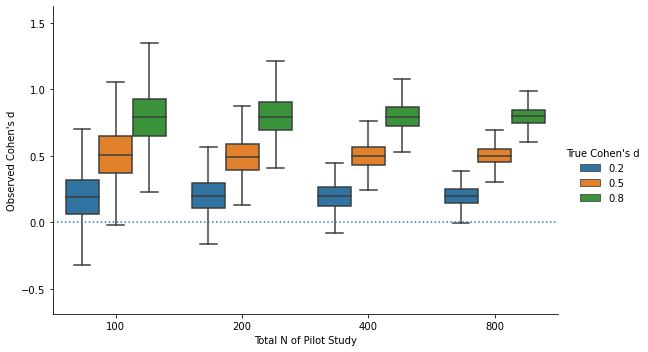

In [2]:
def simulate_experiments(true_d=0.5, n=100):
    x = np.random.normal(0, 1, n)
    y = np.random.normal(0 + true_d, 1, n)
    ttest = pg.ttest(x, y)
    d = ttest.loc["T-test", "cohen-d"]
    t = ttest.loc["T-test", "T"]
    return -d if t > 0 else d


results = np.array(
    [
        [[simulate_experiments(d, n) for i in range(1000)] for d in [0.2, 0.5, 0.8]]
        for n in [50, 100, 200, 400]
    ]
)
i, d, n = np.array(
    list(product(np.arange(1000), [0.2, 0.5, 0.8], [50, 100, 200, 400]))
).T
df = pd.DataFrame(
    {"results": results.T.flatten(), "i": i, "d": d, "n": n.astype(int) * 2}
)
g = sns.catplot(
    data=df,
    hue="d",
    x="n",
    y="results",
    dodge=2,
    kind="box",
    fliersize=0,
    legend=False,
    height=5,
    aspect=8 / 5,
)
g.ax.axhline(0, ls=":")
g.add_legend(title="True Cohen's d")
g.set_ylabels("Observed Cohen's d")
g.set_xlabels("Total N of Pilot Study")
fig = plt.gcf()
plt.close()
display(fig, metadata=dict(filename="Fig1"));

The graph below show the boxplots of observed Cohen's d in simulated pilot studies. We can see that, to reliably distinguish "small", "medium", and "large" effects, you need sample sizes in excess of 400. 

And with such sample sizes, most pilot studies would already give you significant results... which negates the point of running the pilot study!

So that's already a threat to the argument: **It is very unlikely that researchers can "bull's-eye" their effect size prediction.**

## Will A Careful Power Analysis Lead to Larger P-Values?

But let's set this concern aside, and assume that a researcher was able, through some combination of pilot studies, meta-analysis of existing studies, and lucky guesswork, to obtain a perfectly accurate estimate of the effect size that they want to study. For the sake of illustration, let's assume that this effect size is d = 0.5.

Now, the researcher can use this perfectly-estimated effect size to run a power analysis: How many participants will they need to detect this effect X% of the time? 

The graph below shows the relationship between target power and number of participants needed:

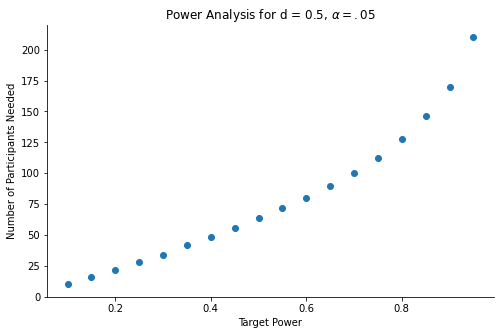

In [3]:
powers = np.arange(0.05, 0.99, 0.05)
n_needed = [np.round(pg.power.power_ttest(d=0.5, power=p), 0) * 2 for p in powers]
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.scatter(powers, n_needed)
ax.set_xlabel("Target Power")
ax.set_ylabel("Number of Participants Needed")
ax.set_title("Power Analysis for d = 0.5, $\\alpha = .05$")
sns.despine()
plt.close()
display(fig, metadata=dict(filename="Fig2"));

The level of power the researcher will chose depends on their tolerance for false-negative findings, but it is not unreasonable to assume that they will want to detect the effect at least half of the time.

Now, with a sample size giving them at least 50% power to detect their perfectly-predicted effect size, how often would the researcher obtain p-values close to .05?

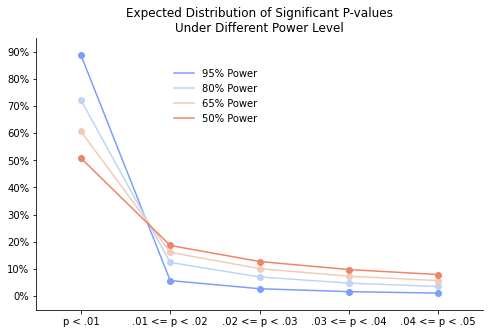

In [6]:
TRUE_D = 0.5
pval_dists = {}
POWERS = [0.5, 0.65, 0.80, 0.95]
pvals_range = [0, 0.01, 0.02, 0.03, 0.04, 0.05]
for POWER in POWERS:
    # N required to achieve a given level of power
    req_n = pg.power_ttest(d=TRUE_D, power=POWER)
    # Critical value of central F distribution at alpha = .05
    critval = f._ppf(0.95, 1, req_n - 2)
    # We compute the non-centrality parameter at this critical value
    ncp = ncfdtrinc(1, req_n - 2, 1 - POWER, critval)
    pval_dist = np.diff(
        [
            ncf._sf(f.ppf(1 - pcrit, 1, req_n - 2), 1, req_n - 2, ncp)
            for pcrit in pvals_range
        ]
    )
    pval_dists[POWER] = pval_dist / pval_dist.sum()
fig, ax = plt.subplots(
    1, 1, figsize=(8, 5), sharex=True, sharey="row", facecolor="white"
)
for p, c in zip(POWERS[::-1], sns.color_palette("coolwarm", 4)):
    pval_dist = pval_dists[p]
    ax.plot(pvals_range[1:], pval_dist, label=f"{p*100:.0f}% Power", color=c)
    ax.scatter(pvals_range[1:], pval_dist, label="_", color=c)

ax.set_title(
    "Expected Distribution of Significant P-values\nUnder Different Power Level"
)
ax.set_xlim(0.005, 0.055)
ax.set_ylim(-0.05, 0.95)
ax.set_xticks([0.01, 0.02, 0.03, 0.04, 0.05])
ax.set_yticks(np.arange(0, 0.95, 0.1))
ax.set_yticklabels([f"{v*100:.0f}%" for v in np.arange(0, 0.95, 0.1)])
ax.set_xticklabels(
    ["p < .01", ".01 <= p < .02", ".02 <= p < .03", ".03 <= p < .04", ".04 <= p < .05"]
)
sns.despine()
plt.legend(frameon=False, loc=(0.3, 0.67))
plt.close()
display(fig, metadata=dict(filename="Fig3"));

The graph shows that, under all reasonable levels of power, "large" p-values will be rare: Even at 50% power (a very low target power, that I've never seen used in any power analysis), more than 50% of the significant p-values will be lower than .01.

## Conclusion

**Researchers cannot "aim" for p = .05, not even with a careful, perfectly accurate, power analysis.**

In fact, the opposite is true: If their power analysis is accurate (i.e., gives them a good chance to detect their effect), they should get p-values that are much smaller, rather than close, to .05.

The most likely explanation for a set of multiple p-values hugging .05 is low statistical power, and/or p-hacking.